# SmartSpend — Financial Health Classifier & Savings Predictor

Model dua-output berbasis **TensorFlow Functional API** untuk analisis kondisi keuangan personal dari data tabular.

| Komponen | Detail |
|---|---|
| **Arsitektur** | Two-tower multi-output network |
| **Output 1** | Klasifikasi kondisi keuangan (`label_rekomendasi`) |
| **Output 2** | Prediksi nominal tabungan bulanan (`tabungan_bulanan`) |
| **Training** | Custom loop via `tf.GradientTape` dengan LR decay dan early stopping |
| **Dataset** | `dataset_finansial.csv` |

## 1. Imports

In [19]:
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from tensorflow.keras import Model, layers

# tf.random.set_seed(42)
# np.random.seed(42)

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.20.0


## 2. Data Loading & Preprocessing

Dataset berisi rekaman keuangan personal bulanan. Dua fitur turunan ditambahkan sebelum encoding dan normalisasi:

- **`sisa_pendapatan`** — pendapatan setelah dikurangi total pengeluaran
- **`estimasi_tabungan`** — pendapatan setelah dikurangi pengeluaran dan cicilan hutang

Ketiga preprocessor disimpan ke disk agar pipeline inference dapat mereplikasi transformasi yang identik.

In [20]:
df = pd.read_csv('dataset_finansial.csv')
df.drop(columns=['id'], inplace=True, errors='ignore')

# Derived features
df['sisa_pendapatan']   = df['pendapatan_bulanan'] - df['total_pengeluaran']
df['estimasi_tabungan'] = df['pendapatan_bulanan'] - df['total_pengeluaran'] - df['cicilan_hutang']
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Targets
label_encoder = LabelEncoder()
y_class       = label_encoder.fit_transform(df['label_rekomendasi'])
target_scaler = MinMaxScaler()
y_reg         = target_scaler.fit_transform(df[['tabungan_bulanan']])

# Features
X              = df.drop(columns=['tabungan_bulanan', 'label_rekomendasi'])
X_encoded      = pd.get_dummies(X, drop_first=True)
feature_scaler = StandardScaler()
X_scaled       = feature_scaler.fit_transform(X_encoded)

# Train / test split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_class, y_reg, test_size=0.2, random_state=42
)

# Persist preprocessors
joblib.dump(target_scaler,  'target_scaler.pkl')
joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(label_encoder,  'label_encoder.pkl')

print(f"Samples   — train : {len(X_train):,}  |  test : {len(X_test):,}")
print(f"Features  — {X_train.shape[1]}")
print(f"Classes   — {list(label_encoder.classes_)}")

Samples   — train : 1,720  |  test : 430
Features  — 50
Classes   — ['Cukup Baik', 'Keuangan Sehat', 'Perlu Perbaikan']


## 3. Arsitektur Model

Network terdiri dari dua cabang yang berbagi satu input layer.

```
Input (n_features)
    │
    ├─── Classification tower ─── Dense(128, relu) → Dropout(0.3)
    │                              → Dense(64, relu) → Dropout(0.2) → Softmax
    │
    └─── Regression tower ──────── Dense(16, relu)
                                   → Concatenate([input, Dense(16)]) → Linear
```

Skip-connection pada regression tower mempertahankan hubungan linear antara fitur keuangan mentah
dengan nominal tabungan, tanpa mengorbankan kapasitas ekspresi non-linear.

In [21]:
input_dim = X_train.shape[1]
n_classes = len(label_encoder.classes_)

inputs = layers.Input(shape=(input_dim,), name='input_features')

# Classification tower
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
clf_output = layers.Dense(n_classes, activation='softmax', name='clf_output')(x)

# Regression tower with residual skip-connection
r = layers.Dense(16, activation='relu')(inputs)
r = layers.Concatenate()([inputs, r])
reg_output = layers.Dense(1, activation='linear', name='reg_output')(r)

model = Model(inputs=inputs, outputs=[clf_output, reg_output], name='SmartSpendNet')
model.summary()

Model: "SmartSpendNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      6,528 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        816 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 66)        │          0 │ input_features[0… │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clf_output (Dense)  │ (None, 3)         │        195 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_output (Dense)  │ (None, 1)         │         67 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,862 (61.96 KB)

 Trainable params: 15,862 (61.96 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Custom Callback — `TrainingMonitor`

Mencatat metrik validasi per epoch ke JSON dan mencetak ringkasan berkala.
Callback ini dirancang untuk digunakan bersama `model.fit()`. Pada training loop manual
di bagian berikutnya, monitoring dilakukan secara inline di dalam loop.

In [22]:
class TrainingMonitor(tf.keras.callbacks.Callback):
    """Logs per-epoch validation metrics and serialises the training history.

    Parameters
    ----------
    log_path : str
        Destination path for the JSON history file.
    print_freq : int
        Print a summary row every this many epochs.
    target_acc : float
        Minimum validation accuracy that is considered satisfactory.
    target_mae : float
        Maximum validation MAE (normalised scale) considered satisfactory.
    """

    def __init__(
        self,
        log_path: str   = 'training_history.json',
        print_freq: int = 5,
        target_acc: float = 0.85,
        target_mae: float = 0.02,
    ) -> None:
        super().__init__()
        self.log_path   = log_path
        self.print_freq = print_freq
        self.target_acc = target_acc
        self.target_mae = target_mae
        self._log: list[dict] = []

    def on_train_begin(self, logs=None) -> None:
        n = self.params.get('epochs', '?')
        print(f"Training started — {n} epochs scheduled")
        print(f"{'epoch':>6}  {'val_loss':>9}  {'val_acc':>8}  {'val_mae':>8}")
        print("-" * 38)

    def on_epoch_end(self, epoch: int, logs=None) -> None:
        logs = logs or {}
        rec = {
            'epoch'   : epoch + 1,
            'val_loss' : round(float(logs.get('val_loss', float('inf'))), 4),
            'val_acc'  : round(float(logs.get('val_clf_output_accuracy', 0.0)), 4),
            'val_mae'  : round(float(logs.get('val_reg_output_mae',       0.0)), 4),
        }
        self._log.append(rec)

        if (epoch + 1) % self.print_freq == 0:
            flag = '  *' if rec['val_acc'] >= self.target_acc and rec['val_mae'] <= self.target_mae else ''
            print(
                f"{rec['epoch']:>6}  "
                f"{rec['val_loss']:>9.4f}  "
                f"{rec['val_acc']:>8.4f}  "
                f"{rec['val_mae']:>8.4f}"
                f"{flag}"
            )

    def on_train_end(self, logs=None) -> None:
        with open(self.log_path, 'w') as fh:
            json.dump(self._log, fh, indent=2)
        print(f"\nTraining complete. History saved to '{self.log_path}'")

## 5. Custom Training Loop — `tf.GradientTape`

Loop manual memberikan kontrol penuh atas seluruh proses optimasi.

**Composite loss:** `L = L_clf + 10 × L_reg`  
Faktor `10` digunakan untuk menyeimbangkan skala kedua loss agar gradient tidak didominasi oleh salah satu head.

**Adaptive learning rate:** LR dikurangi 50% setiap kali validasi MAE tidak membaik selama `LR_PATIENCE` epoch berturut-turut.

**Early stopping:** Training dihentikan jika tidak ada perbaikan MAE selama `PATIENCE` epoch.

In [23]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 150
PATIENCE     = 30
LR_PATIENCE  = 5
LR_INIT      = 2e-3
REG_WEIGHT   = 10.0      # scale factor to balance clf and reg losses
CHECKPOINT   = 'smartspend_best.keras'
HISTORY_PATH = 'training_history.json'

# ── Dataset pipelines ─────────────────────────────────────────────────────────
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_class_train, y_reg_train))
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
)
val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_class_test, y_reg_test))
    .batch(BATCH_SIZE)
)

# ── Loss functions, optimiser & metrics ───────────────────────────────────────
loss_clf  = tf.keras.losses.SparseCategoricalCrossentropy()
loss_reg  = tf.keras.losses.MeanAbsoluteError()
optimiser = tf.keras.optimizers.Adam(learning_rate=LR_INIT)

m_train_acc = tf.keras.metrics.SparseCategoricalAccuracy()
m_train_mae = tf.keras.metrics.MeanAbsoluteError()
m_val_acc   = tf.keras.metrics.SparseCategoricalAccuracy()
m_val_mae   = tf.keras.metrics.MeanAbsoluteError()


@tf.function
def train_step(x, y_c, y_r):
    with tf.GradientTape() as tape:
        logits, pred_r = model(x, training=True)
        total_loss     = loss_clf(y_c, logits) + REG_WEIGHT * loss_reg(y_r, pred_r)
    grads = tape.gradient(total_loss, model.trainable_weights)
    optimiser.apply_gradients(zip(grads, model.trainable_weights))
    m_train_acc.update_state(y_c, logits)
    m_train_mae.update_state(y_r, pred_r)
    return total_loss


@tf.function
def val_step(x, y_c, y_r):
    logits, pred_r = model(x, training=False)
    m_val_acc.update_state(y_c, logits)
    m_val_mae.update_state(y_r, pred_r)


# ── Training loop ─────────────────────────────────────────────────────────────
best_mae   = float('inf')
no_improve = 0
no_imp_lr  = 0
history_log: list[dict] = []

print(f"{'epoch':>6}  {'val_acc':>8}  {'val_mae':>8}  {'lr':>10}")
print("-" * 42)

for epoch in range(EPOCHS):
    for x_b, yc_b, yr_b in train_ds:
        train_step(x_b, yc_b, yr_b)
    for x_b, yc_b, yr_b in val_ds:
        val_step(x_b, yc_b, yr_b)

    ep_acc = float(m_val_acc.result())
    ep_mae = float(m_val_mae.result())
    ep_lr  = optimiser.learning_rate.numpy()

    history_log.append({'epoch': epoch + 1, 'val_acc': round(ep_acc, 4), 'val_mae': round(ep_mae, 4)})

    if (epoch + 1) % 5 == 0:
        flag = '  <- target met' if ep_acc >= 0.85 and ep_mae <= 0.02 else ''
        print(f"{epoch+1:>6}  {ep_acc:>8.4f}  {ep_mae:>8.4f}  {ep_lr:>10.6f}{flag}")

    for m in [m_train_acc, m_train_mae, m_val_acc, m_val_mae]:
        m.reset_state()

   # Checkpoint & learning rate schedule
    if ep_mae < best_mae:
        best_mae   = ep_mae
        no_improve = 0
        no_imp_lr  = 0
        model.save(CHECKPOINT)
    else:
        no_improve += 1
        no_imp_lr  += 1

        if no_imp_lr >= LR_PATIENCE:
            model.load_weights(CHECKPOINT)

            new_lr = max(optimiser.learning_rate.numpy() * 0.5, 1e-6)
            optimiser.learning_rate.assign(new_lr)
            no_imp_lr = 0
            print(f"  [LR Decay] Teleportasi ke best_weights. LR baru: {new_lr:.6f}")

        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1} "
                  f"(no MAE improvement for {PATIENCE} epochs).")
            break

with open(HISTORY_PATH, 'w') as fh:
    json.dump(history_log, fh, indent=2)

print(f"\nBest val MAE : {best_mae:.4f}")
print(f"Checkpoint   : '{CHECKPOINT}'")

 epoch   val_acc   val_mae          lr
------------------------------------------
     5    0.8140    0.1201    0.002000
    10    0.8488    0.0657    0.002000
    15    0.8651    0.0455    0.002000
    20    0.8651    0.0363    0.002000
    25    0.8767    0.0299    0.002000
    30    0.8791    0.0326    0.002000
    35    0.8837    0.0261    0.002000
    40    0.8791    0.0244    0.002000
    45    0.8721    0.0225    0.002000
    50    0.8767    0.0247    0.002000
  [LR Decay] Teleportasi ke best_weights. LR baru: 0.001000
    55    0.8744    0.0187    0.001000  <- target met
    60    0.8837    0.0180    0.001000  <- target met
    65    0.8791    0.0188    0.001000  <- target met
  [LR Decay] Teleportasi ke best_weights. LR baru: 0.000500
    70    0.8884    0.0158    0.000500  <- target met
    75    0.8907    0.0170    0.000500  <- target met
  [LR Decay] Teleportasi ke best_weights. LR baru: 0.000250
    80    0.8907    0.0151    0.000250  <- target met
    85    0.8860    0.01

## 6. Training Curves

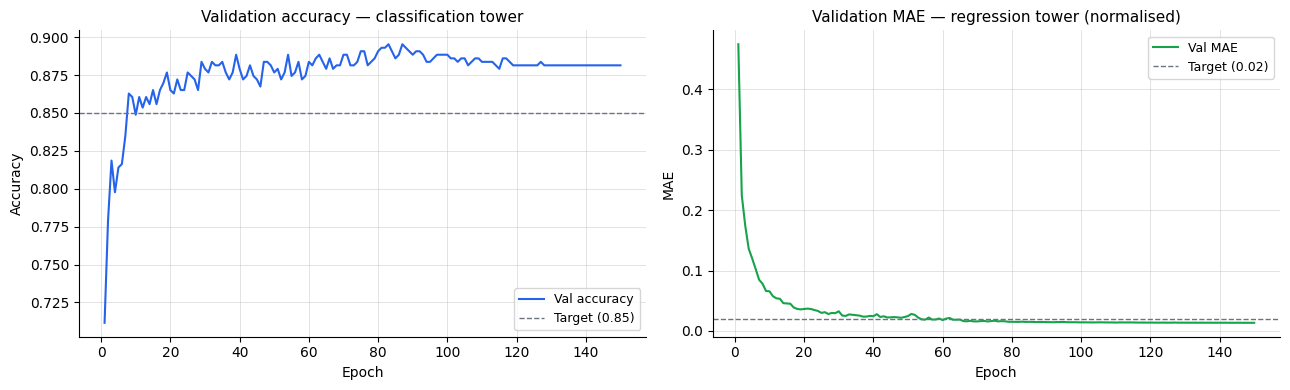

In [24]:
epochs_x = [r['epoch']   for r in history_log]
val_accs  = [r['val_acc'] for r in history_log]
val_maes  = [r['val_mae'] for r in history_log]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_x, val_accs, linewidth=1.5, color='#2563eb', label='Val accuracy')
axes[0].axhline(0.85, color='#6b7280', linewidth=1, linestyle='--', label='Target (0.85)')
axes[0].set_title('Validation accuracy — classification tower', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, linewidth=0.5, alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(epochs_x, val_maes, linewidth=1.5, color='#16a34a', label='Val MAE')
axes[1].axhline(0.02, color='#6b7280', linewidth=1, linestyle='--', label='Target (0.02)')
axes[1].set_title('Validation MAE — regression tower (normalised)', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=9)
axes[1].grid(True, linewidth=0.5, alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Final

Model terbaik (checkpoint dengan val MAE terendah) dimuat kembali dan dievaluasi pada test set.
Metrik regresi dilaporkan dalam mata uang asli (IDR) setelah inverse-transform dari skala MinMax.

Classification report

                 precision    recall  f1-score   support

     Cukup Baik       0.80      0.89      0.84       149
 Keuangan Sehat       0.96      0.97      0.96       236
Perlu Perbaikan       0.69      0.40      0.51        45

       accuracy                           0.88       430
      macro avg       0.82      0.75      0.77       430
   weighted avg       0.88      0.88      0.87       430

Regression metrics (IDR)
  MAE  : Rp        100,572
  RMSE : Rp        379,189
  MAPE : 6572737.28%


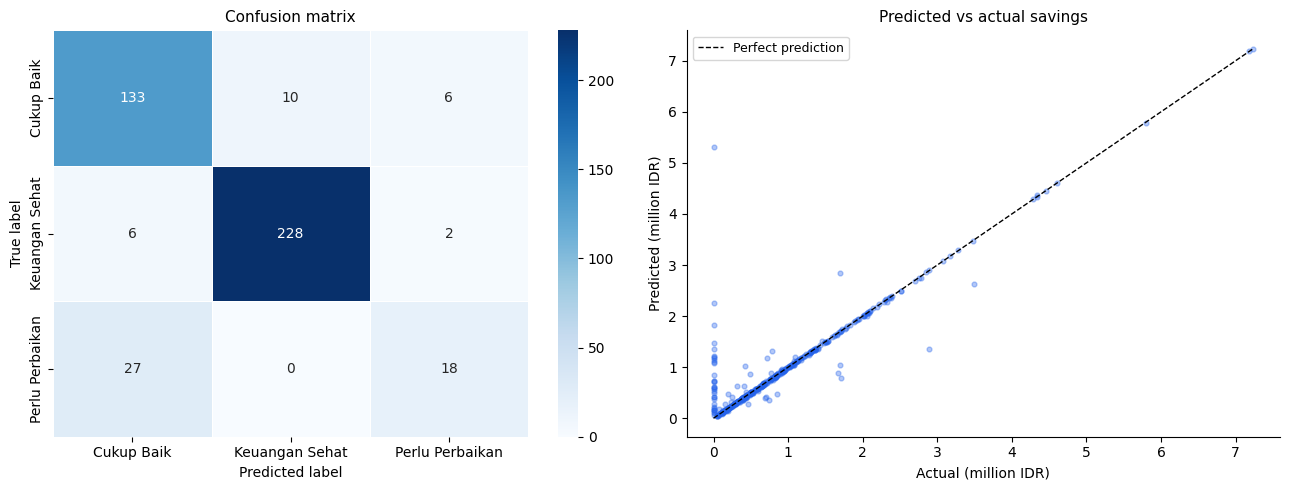

In [25]:
best_model = tf.keras.models.load_model(CHECKPOINT)
best_model.compile(
    optimizer='adam',
    loss={'clf_output': 'sparse_categorical_crossentropy', 'reg_output': 'mae'},
    metrics={'clf_output': 'accuracy', 'reg_output': 'mae'},
)

# Predictions on test set
clf_probs, reg_scaled = best_model.predict(X_test, verbose=0)
clf_labels            = np.argmax(clf_probs, axis=1)

reg_pred_idr = target_scaler.inverse_transform(reg_scaled).flatten()
reg_true_idr = target_scaler.inverse_transform(y_reg_test).flatten()

# Regression metrics (IDR)
mae  = np.mean(np.abs(reg_pred_idr - reg_true_idr))
rmse = np.sqrt(np.mean((reg_pred_idr - reg_true_idr) ** 2))
mape = np.mean(
    np.abs((reg_pred_idr - reg_true_idr) / np.where(reg_true_idr == 0, 1, reg_true_idr))
) * 100

# ── Classification report ──────────────────────────────────────────────────────
print("Classification report\n")
print(classification_report(y_class_test, clf_labels, target_names=label_encoder.classes_))

# ── Regression metrics ─────────────────────────────────────────────────────────
print("Regression metrics (IDR)")
print(f"  MAE  : Rp {mae:>14,.0f}")
print(f"  RMSE : Rp {rmse:>14,.0f}")
print(f"  MAPE : {mape:.2f}%")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_class_test, clf_labels)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
)
axes[0].set_title('Confusion matrix', fontsize=11)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

max_val = max(reg_true_idr.max(), reg_pred_idr.max()) / 1e6
axes[1].scatter(reg_true_idr / 1e6, reg_pred_idr / 1e6, alpha=0.35, s=12, color='#2563eb')
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_title('Predicted vs actual savings', fontsize=11)
axes[1].set_xlabel('Actual (million IDR)')
axes[1].set_ylabel('Predicted (million IDR)')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Inference Pipeline

Memuat ulang semua artefak dari disk dan menjalankan prediksi pada satu sampel untuk memverifikasi
pipeline end-to-end. Urutan transformasi di sini harus identik dengan yang diterapkan saat training.

In [26]:
# Load artefacts
infer_model  = tf.keras.models.load_model(CHECKPOINT)
feat_scaler  = joblib.load('feature_scaler.pkl')
tgt_scaler   = joblib.load('target_scaler.pkl')
lbl_encoder  = joblib.load('label_encoder.pkl')

# Sample data (row index 5 from the original dataset)
df_raw  = pd.read_csv('dataset_finansial.csv')
sample  = df_raw.iloc[[5]].copy()

true_label   = sample['label_rekomendasi'].values[0]
true_savings = sample['tabungan_bulanan'].values[0]

sample.drop(columns=['tabungan_bulanan', 'label_rekomendasi', 'id'], inplace=True, errors='ignore')

# Apply the same transformation pipeline as training
sample.replace([np.inf, -np.inf], np.nan, inplace=True)
sample.fillna(0, inplace=True)
sample['sisa_pendapatan']   = sample['pendapatan_bulanan'] - sample['total_pengeluaran']
sample['estimasi_tabungan'] = (
    sample['pendapatan_bulanan'] - sample['total_pengeluaran'] - sample['cicilan_hutang']
)

sample_enc     = pd.get_dummies(sample)
sample_aligned = (
    sample_enc
    .reindex(columns=feat_scaler.feature_names_in_, fill_value=0)
    .astype(float)
)
sample_scaled  = feat_scaler.transform(sample_aligned)

# Predict
clf_probs, reg_scaled = infer_model.predict(sample_scaled, verbose=0)
pred_label   = lbl_encoder.inverse_transform([np.argmax(clf_probs)])[0]
pred_savings = tgt_scaler.inverse_transform(reg_scaled)[0][0]

# Results
print("Inference result")
print(f"  Predicted class   : {pred_label}")
print(f"  True class        : {true_label}")
print(f"  Predicted savings : Rp {pred_savings:>12,.0f}")
print(f"  True savings      : Rp {true_savings:>12,.0f}")
print(f"  Absolute error    : Rp {abs(true_savings - pred_savings):>12,.0f}")

Inference result
  Predicted class   : Cukup Baik
  True class        : Cukup Baik
  Predicted savings : Rp    1,113,591
  True savings      : Rp    1,108,000
  Absolute error    : Rp        5,591
